 A/B Experiment: Landing Page Optimization for an E-commerce Platform

## Project Summary

This notebook documents a complete A/B testing analysis for an e-commerce company that ran a controlled experiment on its landing page (version A vs. version B) during January 2026. The goal was to determine which version should be deployed based on **conversion rate**, **average spend per converted user**, and **behavioral segmentation** by traffic source and user type.

The dataset contains **40,000 unique users** evenly split between both variants (~20K each), with records spanning January 1–28, 2026.

> ⚠️ **Language note:** The code, comments, and inline analysis throughout this notebook are written in **Spanish**. This introductory section provides an English-language overview for portfolio and professional reference.

---

## Business Context

The marketing team needed a data-driven decision on which landing page version to implement permanently. Beyond the headline A-vs-B comparison, stakeholders also wanted to understand whether the results hold across traffic channels (Organic, Ads, Email, Referral) and user segments (new vs. returning visitors).

---

## Statistical Tests Performed

| # | Business Question | Test | Statistic | p-value | Result |
|---|---|---|---|---|---|
| 1 | Is there a significant difference in average spend per converted user between pages A and B? | Independent samples t-test | t = −9.37 | 1.06 × 10⁻²⁰ | **Reject H₀** — Page B generates significantly higher spend |
| 2 | Does conversion rate differ between pages A and B? | Two-proportion z-test | z = −9.68 | 3.76 × 10⁻²² | **Reject H₀** — Page B converts at a significantly higher rate |
| 3 | Is conversion associated with traffic source? | Chi-square test of independence | χ² = 8.66 | 0.034 | **Reject H₀** — Conversion varies by channel |
| 4 | Is conversion associated with user type (new vs. returning)? | Chi-square test of independence | χ² = 0.51 | 0.474 | **Fail to reject H₀** — No significant difference |

All tests used α = 0.05.

---

## Key Metrics

| Metric | Page A | Page B |
|---|---|---|
| Users exposed | 19,982 | 20,018 |
| Users converted | 2,512 | 3,194 |
| Conversion rate | 12.6% | 16.0% |

- **Average spend (converted users, overall):** $65.37 (range: $12.12–$303.68)
- **Page B outperforms A** on both conversion rate (+3.4 pp) and average spend per converted user.

---

## Business Conclusions

1. **Deploy Page B.** It outperforms Page A on every key metric — higher conversion rate, higher average spend — with overwhelming statistical significance (p < 10⁻²⁰ on both tests).

2. **Optimize channel mix.** Traffic source is significantly associated with conversion (p = 0.034). Organic search drives the largest volume, but relative conversion efficiency varies across channels — worth investigating ROI per acquisition dollar.

3. **No need to segment by user type.** New and returning visitors convert at statistically similar rates (p = 0.47), meaning the landing page works equally well for both audiences. No separate treatment is needed.

4. **Revenue impact estimate:** With ~20K users per variant over 28 days, the +3.4 percentage-point lift in conversion rate translates to roughly 680 additional conversions per cycle under Page B — a material revenue increase when multiplied by the $65+ average order value.


# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**: 

- El dataset contiene 40,000 registros y 9 columnas.
- No se observan valores ausentes, ya que todas las columnas tienen 40,000 valores no nulos.

En cuanto a los tipos de dato, en general son coherentes con el contexto del experimento:

* user_id, landing, region, dispositivo, traffic_source y user_type aparecen como variables categóricas (object).
* converted aparece como variable binaria numérica (int64), lo cual es adecuado para analizar conversión.
* gasto aparece como variable numérica continua (float64), lo cual es correcto para analizar gasto.

Sin embargo, la columna date aparece como object, cuando idealmente debería convertirse a tipo fecha (datetime) para facilitar análisis temporales si fueran necesarios.

En esta etapa, el dataset se ve completo y utilizable para continuar con la validación y el análisis del experimento A/B.



**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
df["user_id"].duplicated().sum()

0

In [ ]:
df["user_id"].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df[df["converted"] == 1]["gasto"].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:

# Explorar variables categóricas y cómo se distribuyen

print("\nConteo de categorías:")
for col in ["landing", "region", "dispositivo", "traffic_source", "user_type"]:
    print(f"{col}:\n{df[col].value_counts()}\n")



Conteo de categorías:
landing:
B    20018
A    19982
Name: landing, dtype: int64

region:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

dispositivo:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

traffic_source:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

user_type:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64



✍️ **Comentario**: Haz doble clic en este bloque y escribe qué ves

Las variables categóricas principales del experimento (landing, region, dispositivo, traffic_source y user_type) presentan categorías consistentes y esperadas, sin valores extraños ni etiquetas mal escritas.

La variable landing, que define los grupos del experimento A/B, está correctamente balanceada: la versión B tiene 20,018 usuarios y la versión A 19,982, lo que sugiere una asignación equilibrada entre ambos grupos. En las demás variables también se observan categorías coherentes para el análisis: cinco regiones, dos tipos de dispositivo, cuatro fuentes de tráfico y dos tipos de usuario.

En términos de distribución, se observa mayor volumen en Mobile que en Desktop, predominio del tráfico Organic y mayor cantidad de usuarios Nuevos que Recurrentes. En esta etapa no se identifican problemas de calidad en las variables categóricas, por lo que el dataset puede seguir utilizándose para el análisis del experimento.


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df[(df["landing"] == "A") & (df["converted"] == 1)]["gasto"]
gasto_B = df[(df["landing"] == "B") & (df["converted"] == 1)]["gasto"]

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba ...

**Hipótesis nula (H₀):** El gasto promedio de los usuarios que se convirtieron es igual en la página A y en la página B.

**Hipótesis alternativa (H₁):** El gasto promedio de los usuarios que se convirtieron es diferente entre la página A y la página B.

<div class="alert alert-block alert-danger">
<b>Definicion de Hipotesis</b> <a class="tocSkip"></a>

Las hipotesis no fueron definidas o presentan errores conceptuales. Recuerda que la hipotesis nula (H0) establece que no existe diferencia entre grupos (ej: el gasto promedio en Landing A es igual al de Landing B), mientras que la alternativa (H1) plantea que si existe una diferencia significativa.

</div>

In [ ]:
# Aplicar prueba
from scipy.stats import ttest_ind

# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico t: {t_stat}")
print(f"Valor p: {p_value}")

Estadístico t: -9.36563589591332
Valor p: 1.0635288333792346e-20


### 📝 Conclusión e interpretación

**Decisión: Se rechaza la hipótesis nula**  
sí hay evidencia estadística de que el gasto promedio de los usuarios convertidos es diferente entre la página A y la página B.


**Interpretación de negocio:**  
Los resultados indican que existe una diferencia estadísticamente significativa en el gasto promedio de los usuarios que compraron entre la página A y la página B. En particular, el estadístico t negativo sugiere que la página B genera un mayor gasto promedio por comprador que la página A.

**Recomendación:**
Si el objetivo del negocio es maximizar el valor por usuario convertido, la evidencia sugiere priorizar la implementación de la página B, complementando esta decisión con la revisión de la tasa de conversión para asegurar que también sea favorable.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [16]:
# Número de usuarios convertidos por página
conversiones = df.groupby("landing")["converted"].sum()

# Total de usuarios por página
totales = df.groupby("landing")["converted"].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [17]:
# Aplicar prueba
from statsmodels.stats.proportion import proportions_ztest

# Aplicar prueba
conteos = [conversiones["A"], conversiones["B"]]
num_observaciones = [totales["A"], totales["B"]]

z_stat, p_value = proportions_ztest(conteos, num_observaciones)

# Visualizar resultados
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

Estadístico z: -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀), ya que el valor p es mucho menor que 0.05. Por tanto, existe evidencia estadística de que la tasa de conversión es diferente entre la página A y la página B.

**Interpretación de negocio:**  
Los resultados indican que la página B convierte a una mayor proporción de usuarios que la página A. En términos de negocio, esto sugiere que la versión B es más efectiva para generar conversiones y podría ser la mejor opción si el objetivo principal es maximizar el número de usuarios convertidos.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [18]:
# Tabla de contingencia
tabla_trafico = pd.crosstab(df["traffic_source"], df["converted"])
tabla_trafico

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [19]:
# Aplicar prueba
from scipy.stats import chi2_contingency

# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_trafico)

# Visualizar resultados
print(f"Estadístico chi-cuadrado: {chi2_stat}")
print(f"Valor p: {p_value}")
print(f"Grados de libertad: {dof}")

Estadístico chi-cuadrado: 8.662108841397938
Valor p: 0.0341375947833914
Grados de libertad: 3


In [20]:
alpha = 0.05

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre la fuente de tráfico y la conversión.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre la fuente de tráfico y la conversión.")

Rechazamos la hipótesis nula: hay evidencia de asociación entre la fuente de tráfico y la conversión.


### 📝 Conclusión e interpretación

**Decisión:**
Se rechaza la hipótesis nula (H₀), ya que el valor p es menor que 0.05. Por tanto, existe evidencia estadística de una asociación entre la fuente de tráfico y la conversión.

**Interpretación de negocio:**
Los resultados sugieren que la probabilidad de conversión no es igual en todos los canales de adquisición. En términos de negocio, esto indica que algunas fuentes de tráfico estarían generando conversiones más efectivas que otras, por lo que conviene revisar las tasas de conversión por canal para identificar dónde concentrar esfuerzos e inversión.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [21]:
# Tabla de contingencia
tabla_usuario = pd.crosstab(df["user_type"], df["converted"])
tabla_usuario

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [22]:
from scipy.stats import chi2_contingency

# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_usuario)

# Visualizar resultados
print(f"Estadístico chi-cuadrado: {chi2_stat}")
print(f"Valor p: {p_value}")
print(f"Grados de libertad: {dof}")

Estadístico chi-cuadrado: 0.5134849494478645
Valor p: 0.4736341272301974
Grados de libertad: 1


In [23]:
alpha = 0.05

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre el tipo de usuario y la conversión.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre el tipo de usuario y la conversión.")

No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre el tipo de usuario y la conversión.


### 📝 Conclusión e interpretación

**Decisión:**
No se rechaza la hipótesis nula (H₀), ya que el valor p es mayor que 0.05. Por tanto, no hay evidencia estadística suficiente para afirmar que exista una asociación entre el tipo de usuario y la conversión.

**Interpretación de negocio:**
Los resultados sugieren que, en este experimento, los usuarios nuevos y recurrentes presentan comportamientos de conversión similares. En términos de negocio, esto indica que el tipo de usuario no parece ser un factor diferenciador importante para explicar la conversión en este contexto.

**Recomendación:**
No se recomienda priorizar decisiones o segmentaciones basadas únicamente en user_type, ya que no se observan diferencias estadísticamente significativas en conversión entre nuevos y recurrentes. Sería más útil enfocar la optimización en variables que sí mostraron asociación o diferencias relevantes, como la landing o la fuente de tráfico.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

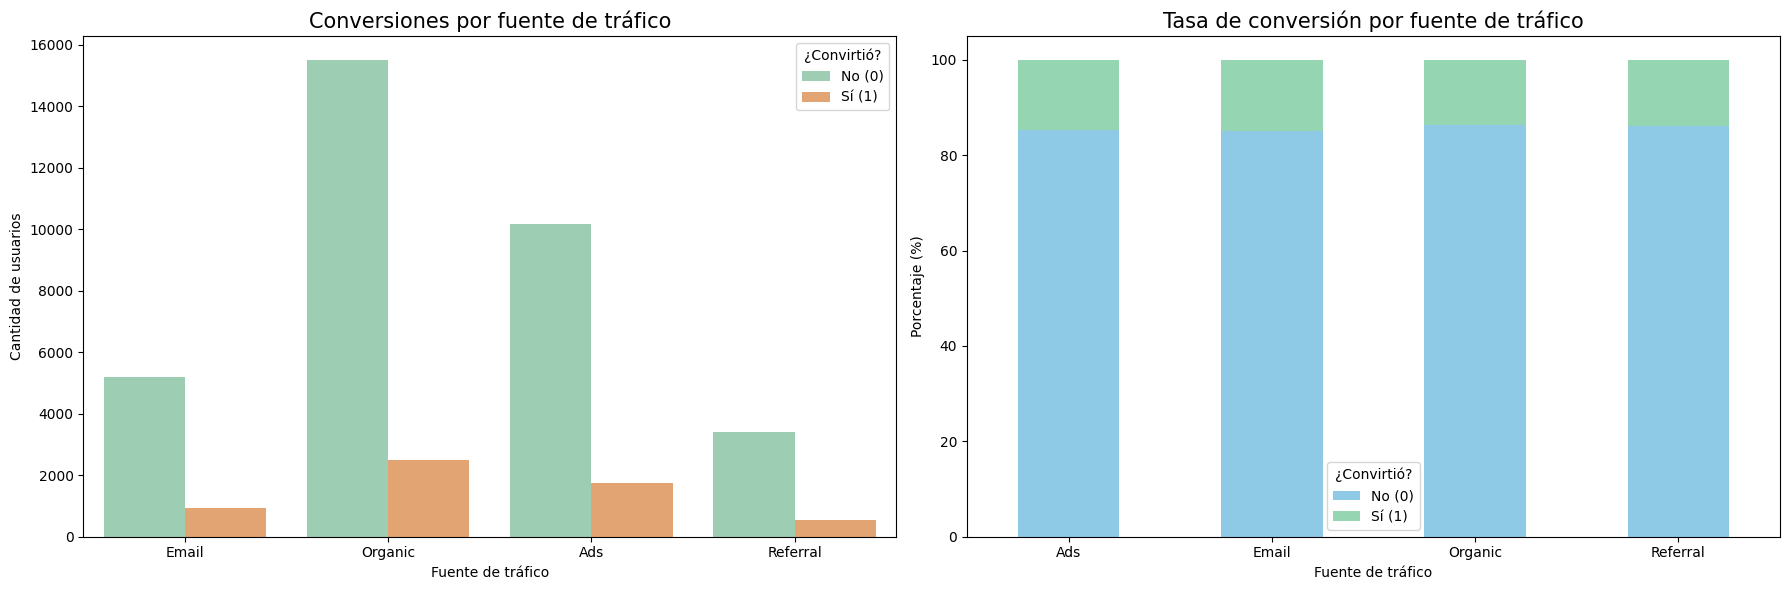

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(data=df, x='traffic_source', hue='converted',
              palette=["#95D5B2", "#F4A261"], ax=axes[0])
axes[0].set_title('Conversiones por fuente de tráfico', fontsize=15)
axes[0].set_xlabel('Fuente de tráfico')
axes[0].set_ylabel('Cantidad de usuarios')
axes[0].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])

tabla_trafico_norm = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100
tabla_trafico_norm.plot(kind='bar', stacked=True, color=["#8ecae6", "#95d5b2"], ax=axes[1])
axes[1].set_title('Tasa de conversión por fuente de tráfico', fontsize=15)
axes[1].set_xlabel('Fuente de tráfico')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Relación entre el tipo de usuario y la conversión

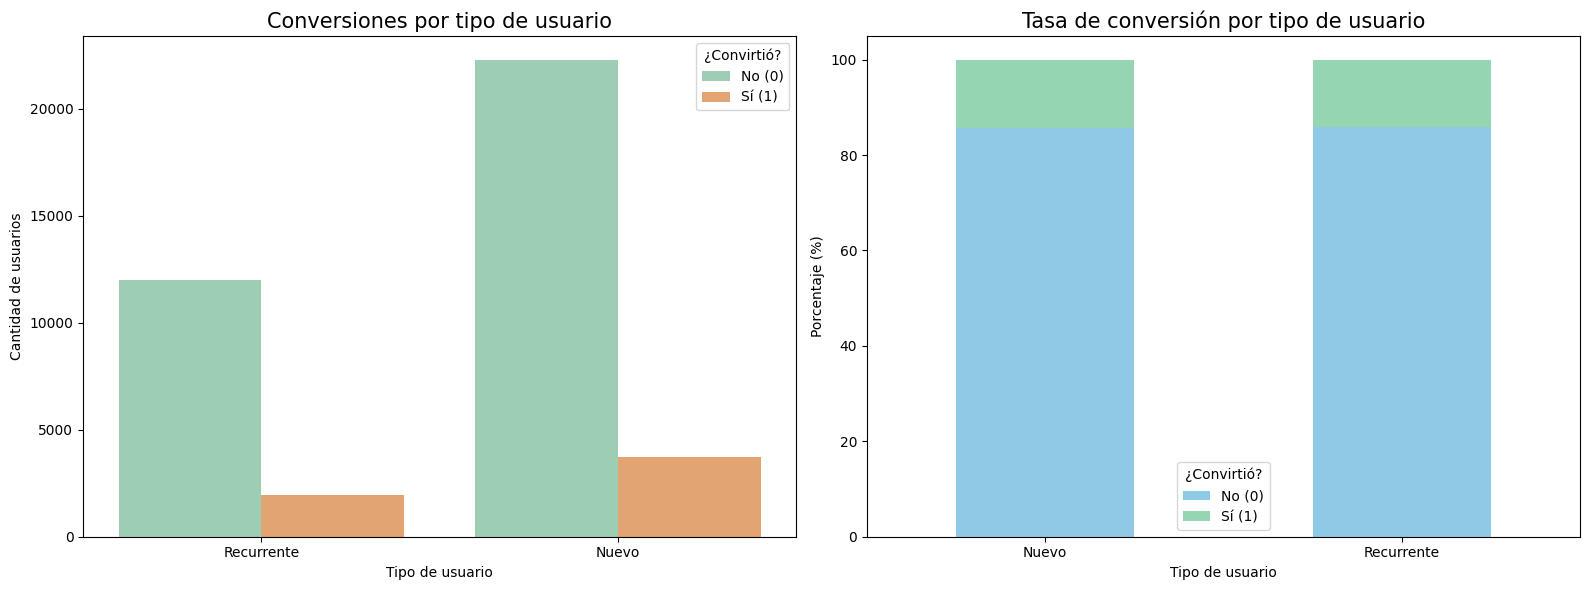

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='user_type', hue='converted',
              palette=["#95D5B2", "#F4A261"], ax=axes[0])
axes[0].set_title('Conversiones por tipo de usuario', fontsize=15)
axes[0].set_xlabel('Tipo de usuario')
axes[0].set_ylabel('Cantidad de usuarios')
axes[0].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])

tabla_usuario_norm = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
tabla_usuario_norm.plot(kind='bar', stacked=True, color=["#8ecae6", "#95d5b2"], ax=axes[1])
axes[1].set_title('Tasa de conversión por tipo de usuario', fontsize=15)
axes[1].set_xlabel('Tipo de usuario')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

✍️ **Comentario**: 

**Gráfico de conteos (barras agrupadas):**
La fuente Organic concentra el mayor volumen de usuarios y también el mayor número absoluto de conversiones, seguida por Ads. En cambio, Referral y Email aportan menos usuarios y menos conversiones en términos absolutos.

**Gráfico de proporciones (barras apiladas)**:
Al comparar porcentajes, las diferencias entre canales parecen relativamente pequeñas, aunque algunos muestran una conversión ligeramente más alta que otros. Esto sugiere que el volumen total cambia bastante entre fuentes, pero la efectividad relativa por canal no es radicalmente distinta y debe interpretarse junto con la prueba chi-cuadrada.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Se encontró una diferencia estadísticamente significativa en el gasto promedio entre la página A y la página B.
- El estadístico t negativo sugiere que la página B genera un mayor gasto promedio por comprador que la página A.
- **Interpretación:** Si el objetivo del negocio es maximizar el valor económico por usuario convertido, la evidencia favorece a la versión B.

<br>


**Tasa de conversión:** 
- La prueba z mostró una diferencia estadísticamente significativa en la tasa de conversión entre la página A y la página B.
- Los resultados indican que la página B convierte una mayor proporción de usuarios que la página A.
- **Interpretación:** La versión B no solo genera mayor gasto promedio por comprador, sino que también convierte a más usuarios, por lo que es la alternativa más sólida para implementar.


---

#### 📊 **Segmentación por fuente de tráfico**
- Se encontró evidencia estadística de una asociación entre la fuente de tráfico y la conversión, lo que indica que el canal de adquisición influye en los resultados del experimento.
- En volumen absoluto, Organic aporta la mayor cantidad de usuarios y también el mayor número de conversiones, mientras que al comparar proporciones las diferencias entre canales parecen más moderadas.
- **Interpretación:** La fuente de tráfico sí importa, pero conviene distinguir entre canales que traen más volumen y canales que convierten relativamente mejor. Organic destaca en escala, mientras que otros canales pueden ser competitivos en eficiencia.
 
 ---

#### 📊 **Segmentación por tipo de usuario**
- No se encontró evidencia estadística suficiente de asociación entre tipo de usuario y conversión.
- Aunque los usuarios nuevos representan mayor volumen total, la probabilidad de conversión entre Nuevos y Recurrentes es similar dentro del experimento analizado.
- **Interpretación:** En este contexto, el tipo de usuario no parece ser un criterio prioritario para segmentar decisiones de conversión, ya que no explica diferencias significativas en el desempeño

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Implementar la página B como versión principal de la landing, ya que mostró mejor desempeño tanto en tasa de conversión como en gasto promedio por comprador.
- Optimizar la estrategia por canal de tráfico, priorizando los canales con mayor volumen y mejor eficiencia relativa, en lugar de segmentar decisiones por tipo de usuario, ya que esta variable no mostró diferencias significativas.

#### **Conclusión final**
Las visualizaciones y las pruebas estadísticas apuntan en la misma dirección: la versión B ofrece un mejor desempeño global, mientras que la fuente de tráfico sí representa una dimensión relevante de optimización y el tipo de usuario no parece aportar diferencias clave en conversión.